## Lab6-Assignment: Topic Classification

Copyright: Vrije Universiteit Amsterdam, Faculty of Humanities, CLTL

Use the same training, development, and test partitions of the the 20 newsgroups text dataset as in Lab6.4-Topic-classification-BERT.ipynb

* Fine-tune and examine the performance of another transformer-based pretrained language models, e.g., RoBERTa, XLNet

* Compare the performance of this model to the results achieved in Lab6.4-Topic-classification-BERT.ipynb and to a conventional machine learning approach (e.g., SVM, Naive Bayes) using bag-of-words or other engineered features of your choice.
Describe the differences in performance in terms of Precision, Recall, and F1-score evaluation metrics.

In this notebook, we demonstrate how to fine-tune BERT for topic classification.

We will use the [simpletransformers library](https://simpletransformers.ai/):
 wrapper for the [huggingface transformers library](https://huggingface.co/) on PyTorch.

# Getting Started

We are running this notebook in [colab](https://colab.research.google.com/?utm_source=scs-index), which has (limited) free access to GPUs.

You'll need to enable a GPU environment for the transformer-based models:

* navigate to Edit → Notebook Settings
* select GPU from the Hardware Accelerator drop-down

#Transformer Based Models

###Prerequisites

Install the simpletransformers library (restart your runtime after the installation)

In [1]:
!pip install simpletransformers --upgrade

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.3/316.3 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 29.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 5.1 MB/s eta 0:00:00
  Created wheel for seqeval: filename=seqeval-1.2.2-py3-none-any.whl size=16162 sha256=6e4f4f9def7e6b3d679ecaf20667d644e45ff3469f583956aa31d2c0e4a8176f
  Stored in directory: /root/.cache/pip/wheels/bc/92/f0/243288f899c2eacdfa8c5f9aede4c71a9bad0ee26a01dc5ead
Successfully built seqeval


##Data set-up
Import [the 20 newsgroups text dataset](https://scikit-learn.org/0.19/datasets/twenty_newsgroups.html).

The dataset contains around 18,000 newsgroups posts on 20 topics.

In [2]:
from sklearn.datasets import fetch_20newsgroups

# load only a sub-selection of the categories (4 in our case)
categories = ['alt.atheism', 'comp.graphics', 'sci.med', 'sci.space']

# remove the headers, footers and quotes (to avoid overfitting)
newsgroups_train = fetch_20newsgroups(subset='train', remove=('headers', 'footers', 'quotes'), categories=categories, random_state=42)
newsgroups_test = fetch_20newsgroups(subset='test', remove=('headers', 'footers', 'quotes'), categories=categories, random_state=42)

### Data exploration

The target attribute is the integer index of the category:

In [3]:
from collections import Counter
Counter(newsgroups_train.target)

Counter({np.int64(3): 593,
         np.int64(1): 584,
         np.int64(2): 594,
         np.int64(0): 480})

In [4]:
Counter(newsgroups_test.target)

Counter({np.int64(1): 389,
         np.int64(2): 396,
         np.int64(0): 319,
         np.int64(3): 394})

Convert data to pandas dataframe

In [5]:
import pandas as pd

train = pd.DataFrame({'text': newsgroups_train.data, 'labels': newsgroups_train.target})
test = pd.DataFrame({'text': newsgroups_test.data, 'labels': newsgroups_test.target})

Use a subset (10%) of the training set as a validation set

In [6]:
from sklearn.model_selection import train_test_split

train, dev = train_test_split(train, test_size=0.1, random_state=0,
                               stratify=train[['labels']])

##XLNet
<a id="XLNet"></a>

###Model's configuration

In [7]:
from simpletransformers.classification import ClassificationArgs

# Model configuration # https://simpletransformers.ai/docs/usage/#configuring-a-simple-transformers-model
model_args = ClassificationArgs()

model_args.overwrite_output_dir=True # overwrite existing saved models in the same directory
model_args.evaluate_during_training=True # to perform evaluation while training the model
# (eval data should be passed to the training method)

model_args.num_train_epochs=10 # number of epochs
model_args.train_batch_size=32 # batch size
model_args.learning_rate=4e-6 # learning rate
model_args.max_seq_length=256 # maximum sequence length
# Note! Increasing max_seq_len may provide better performance, but training time will increase.
# For educational purposes, we set max_seq_len to 256.

# Early stopping to combat overfitting: https://simpletransformers.ai/docs/tips-and-tricks/#using-early-stopping
model_args.use_early_stopping=True
model_args.early_stopping_delta=0.01 # "The improvement over best_eval_loss necessary to count as a better checkpoint"
model_args.early_stopping_metric='eval_loss'
model_args.early_stopping_metric_minimize=True
model_args.early_stopping_patience=2
model_args.evaluate_during_training_steps=32 # how often you want to run validation in terms of training steps (or batches)


With this configuration, the training will terminate if the eval_loss on the evaluation data does not improve upon the best eval_loss by at least 0.01 for 2 consecutive evaluations.

An evaluation will occur once for every 32 training steps.

In [8]:
import numpy as np

# Checking steps per epoch
steps_per_epoch = int(np.ceil(len(train) / float(model_args.train_batch_size)))
print('Each epoch will have {:,} steps.'.format(steps_per_epoch)) # 64 steps = validating 2 times per epoch

Each epoch will have 64 steps.


Load the pre-trained model: model_type = bert; model_name = [bert-base-cased](https://huggingface.co/bert-base-cased) (specifies the exact architecture and trained weights to use)

Fine-tuning the model (takes a while)

* Loss measures the “goodness” of your model

* The smaller the loss, the better the classifier is at modeling the relationship between the input data and the output targets

* But you need to be careful not to overfit

In our case, we stopped training because eval_loss loss did not improve upon the best eval_loss by at least 0.01 for 2 consecutive evaluations.

We can observe fluctuations in the training loss, but overall it is decreasing.
We can have a smoother learning curve by varying hyperparameters, e.g., learning rate, batch size.

* mcc: [ Matthews correlation coefficient](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.matthews_corrcoef.html)

* eval_loss: Cross Entropy Loss for dev

Make predictions with the model (predict the labels of the documents in the test set)

Test set predictions

###Model evaluation
Evaluate the model's performance on the test set

In [9]:
from simpletransformers.classification import ClassificationModel

model_xlnet = ClassificationModel('xlnet', 'xlnet-base-cased', num_labels=4, args=model_args, use_cuda=True) # CUDA is enabled

_, history_xlnet = model_xlnet.train_model(train, eval_df=dev)

result_xl, model_outputs_xl, wrong_predictions_xl = model_xlnet.eval_model(dev)
result_xl

predicted_xl, probabilities_xl = model_xlnet.predict(test.text.to_list())

test['predicted'] = predicted_xl


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/760 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


pytorch_model.bin:   0%|          | 0.00/467M [00:00<?, ?B/s]

Some weights of XLNetForSequenceClassification were not initialized from the model checkpoint at xlnet-base-cased and are newly initialized: ['logits_proj.bias', 'logits_proj.weight', 'sequence_summary.summary.bias', 'sequence_summary.summary.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


...

Running Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/simpletransformers/classification/classification_model.py:1505: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/simpletransformers/classification/classification_model.py:2188: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():


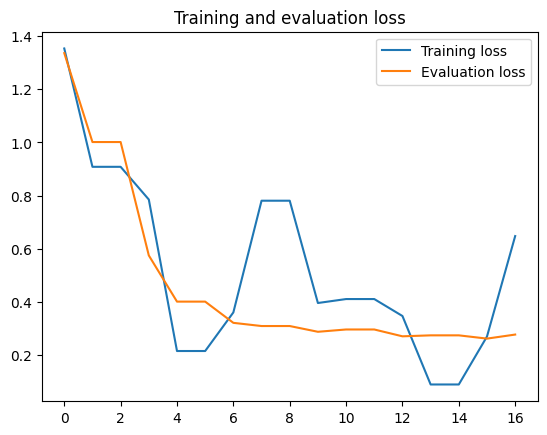

In [10]:
import matplotlib.pyplot as plt

# Plot of loss
train_loss = history_xlnet['train_loss']
eval_loss = history_xlnet['eval_loss']
plt.plot(train_loss, label='Training loss')
plt.plot(eval_loss, label='Evaluation loss')
plt.title('Training and evaluation loss')
plt.legend()

In [11]:
from sklearn.metrics import classification_report

# Result (note: your result can be different due to randomness in operations)
print("XLNET Test Classification Report:")
print(classification_report(test['labels'], test['predicted']))

XLNET Test Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.83      0.82       319
           1       0.89      0.92      0.90       389
           2       0.84      0.90      0.87       396
           3       0.90      0.77      0.83       394

    accuracy                           0.86      1498
   macro avg       0.86      0.86      0.86      1498
weighted avg       0.86      0.86      0.86      1498



##RoBERTa

Most of the set up is the same as we did before with the [XLNet](#XLNet).

###Training

In [12]:
model_roberta = ClassificationModel('roberta', 'roberta-base', num_labels=4, args=model_args, use_cuda=True) # CUDA is enabled

_, history_roberta = model_roberta.train_model(train, eval_df=dev)

result_roberta, model_outputs_roberta, wrong_predictions_roberta = model_roberta.eval_model(dev)
result_roberta

predicted_roberta, probabilities_roberta = model_roberta.predict(test.text.to_list())

test['predicted'] = predicted_roberta

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

...

Running Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/simpletransformers/classification/classification_model.py:1505: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/simpletransformers/classification/classification_model.py:2188: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():


###Evalution

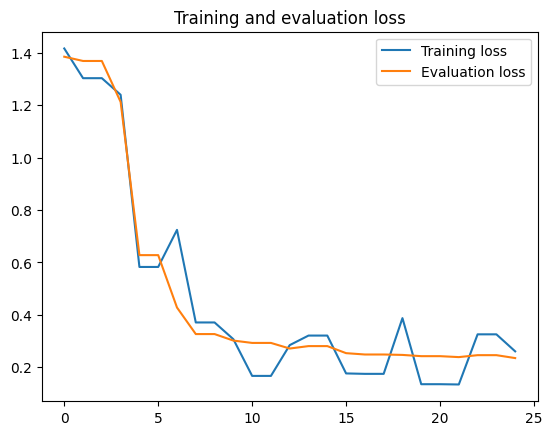

In [13]:
# Plot
train_loss = history_roberta['train_loss']
eval_loss = history_roberta['eval_loss']
plt.plot(train_loss, label='Training loss')
plt.plot(eval_loss, label='Evaluation loss')
plt.title('Training and evaluation loss')
plt.legend()

In [14]:
# Result (note: your result can be different due to randomness in operations)
print("Roberta Test Classification Report:")
print(classification_report(test['labels'], test['predicted']))

Roberta Test Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.82      0.83       319
           1       0.90      0.91      0.90       389
           2       0.87      0.90      0.89       396
           3       0.85      0.82      0.84       394

    accuracy                           0.87      1498
   macro avg       0.86      0.86      0.86      1498
weighted avg       0.86      0.87      0.86      1498



#Support Vector Machine (SVM)
<i>*Code was executed seperately from the other model's to save on GPU resources, hence the duplication of imports.</i>

SVMs classify items based on a separation of the data by drawing boundaries between different categories during training.

##Our Game Plan
We'll set up this classifier in the following steps:
- Load in the news group data
- Create a train/validation split of the data
- Perform feature extraction (To convert to numerical features)
- Train the classifer
- Perform evaluation/Gather statistics

###Loading the data

In [15]:
from sklearn.datasets import fetch_20newsgroups

# load only a sub-selection of the categories (4 in our case)
categories = ['alt.atheism', 'comp.graphics', 'sci.med', 'sci.space']
target_names = categories # For later use in reports

# remove the headers, footers and quotes (to avoid overfitting)
# This is our initial "training" pool, which we will split
newsgroups_train_val = fetch_20newsgroups(
    subset='train',
    remove=('headers', 'footers', 'quotes'),
    categories=categories,
    random_state=42,
)

# This is our final, unseen test set
newsgroups_test = fetch_20newsgroups(
    subset='test',
    remove=('headers', 'footers', 'quotes'),
    categories=categories,
    random_state=42,
)

###Create train/val split

In [16]:
from sklearn.model_selection import train_test_split

# Extract features and target
X_train_val = newsgroups_train_val.data
y_train_val = newsgroups_train_val.target

# Split
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.20,         # 20% for validation
    random_state=42,
    stratify=y_train_val    # Important for classification tasks | https://scikit-learn.org/stable/modules/cross_validation.html#stratification
)

X_test = newsgroups_test.data
y_test = newsgroups_test.target


###Perform feature extraction

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer

# We will use TfidfVectorizer to convert text to numerical features
vectorizer = TfidfVectorizer(
    stop_words='english',
    max_df=0.95,
    min_df=2,
    ngram_range=(1,1), # Consider only unigrams for simplicity
)

X_train_tfidf = vectorizer.fit_transform(X_train)

# Transform validation and test data using the fitted vectorizer
X_val_tfidf = vectorizer.transform(X_val)
X_test_tfidf = vectorizer.transform(X_test)

###Training the classifier

In [18]:
from sklearn.svm import SVC

# We'll use the RBF kernel | It should perform well based on this paper https://link.springer.com/chapter/10.1007/BFb0026683
svm_classifier = SVC(kernel='rbf', C=1.0, gamma=0.8, random_state=42)
svm_classifier.fit(X_train_tfidf, y_train)

SVC(gamma=0.8, random_state=42)

###Evaluation

####Validation set

Validation Accuracy: 0.8736

Validation Classification Report:
               precision    recall  f1-score   support

  alt.atheism       0.98      0.85      0.91        96
comp.graphics       0.82      0.91      0.87       117
      sci.med       0.92      0.86      0.89       119
    sci.space       0.82      0.87      0.84       119

     accuracy                           0.87       451
    macro avg       0.88      0.87      0.88       451
 weighted avg       0.88      0.87      0.87       451



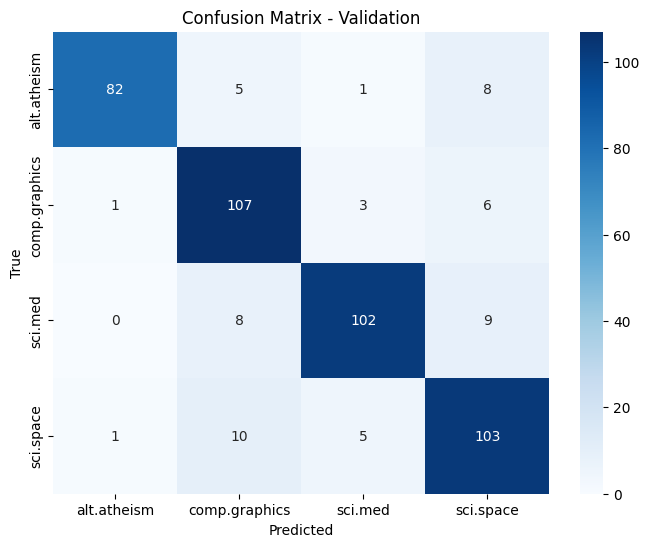

In [20]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

y_val_pred = svm_classifier.predict(X_val_tfidf)

val_accuracy = accuracy_score(y_val, y_val_pred)
print(f"Validation Accuracy: {val_accuracy:.4f}")

print("\nValidation Classification Report:")
print(classification_report(y_val, y_val_pred, target_names=target_names))

cm_val = confusion_matrix(y_val, y_val_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix - Validation')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

####Test set

Test Accuracy: 0.8218

Test Classification Report:
               precision    recall  f1-score   support

  alt.atheism       0.87      0.71      0.78       319
comp.graphics       0.80      0.89      0.84       389
      sci.med       0.90      0.83      0.86       396
    sci.space       0.75      0.84      0.79       394

     accuracy                           0.82      1498
    macro avg       0.83      0.82      0.82      1498
 weighted avg       0.83      0.82      0.82      1498



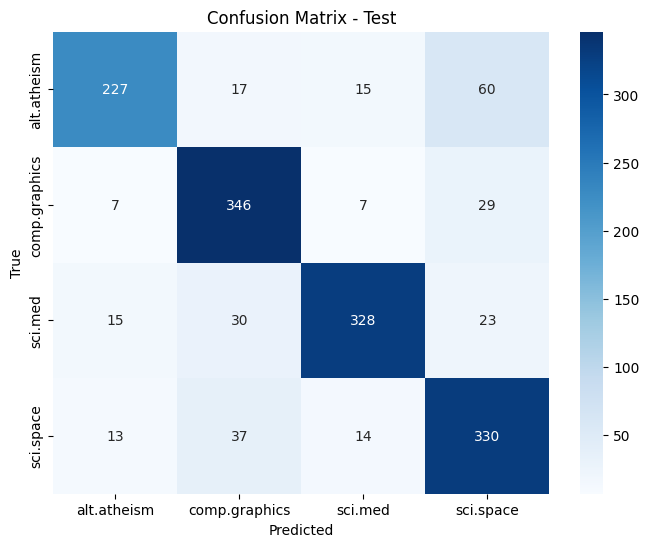

In [21]:
import seaborn as sns
import numpy as np

y_test_pred = svm_classifier.predict(X_test_tfidf)

test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"Test Accuracy: {test_accuracy:.4f}")

print("\nTest Classification Report:")
print(classification_report(y_test, y_test_pred, target_names=target_names))

cm_test = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix - Test')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

#Model Comparisons

| Model    | Accuracy | Macro Precision | Macro Recall | Macro F1 |
|----------|----------|-----------------|--------------|----------|
| RoBERTa  | 0.87     | 0.86            | 0.86         | 0.86     |
| XLNet    | 0.86     | 0.86            | 0.86         | 0.86     |
| SVM      | 0.82     | 0.83            | 0.82         | 0.82     |

The three different models are compared based on the Accuracy, Macro Precision, Macro Recall and Macro F1.\
<i>Since all the three preformed over mutiple class classification, we intent to examine the overall prefromance of every model across all classes.</i>

**Observations:**\
RoBERTa slighlty outprefomed the XLNet model, and had a signifcant leap over the SVM model. In addition, RoBERTa and XLNet showed similar preformance over all the measurements. All the transformer-models are top preforming classifiers, due to the fact that they are transformed-based. The added attention layer over the simple (but nonetheless effective) TF-IDF representation the SVM heavily relies on in combination with multiple layers makes it hard to compete with. Where the SVM shines though are the training time and compute usage. SVMs' relatively simplistic architecture make them more resource efficient.


### End of this notebook.